In [20]:
import pandas as pd
import json
import numpy as np
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
from catomatic.BinaryCatalogue import BinaryBuilder
import pathlib
import matplotlib.cm as cm

from protocols import utils, functions

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Training set

We want to find the best performing parameters on the training set.

In [21]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.3.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 6

In [22]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = functions.prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    phenotypes = functions.prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version, validation=False)
    
    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    cmx, dpr, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cmx, "dpr": dpr, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9, 0.95]:
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


In [23]:
if run_long_processes:

   # run grid search on crypticv1 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.3.0/",
      cryptic_tables_path+"DST_MEASUREMENTS.csv.gz",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/cryptic-v3.3.0/grid_search",
      0.1,
      'v3.3.0',
      'v3.3.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/grid_results_v3.3.0_train.csv')

else: 
   
   df = pd.read_csv('results/grid_search/grid_results_v3.3.0_train.csv')

df

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
0,0,0.0,AMI,0.05,0.90,0.849802,0.982971,0.922734,0.826923,0.984358
1,1,1.0,AMI,0.05,0.95,0.849505,0.983143,0.922436,0.825000,0.984519
2,2,2.0,AMI,0.10,0.90,0.830849,0.983760,0.956011,0.821795,0.984519
3,3,3.0,AMI,0.10,0.95,0.840656,0.983525,0.942571,0.821795,0.984519
4,4,4.0,AMI,0.15,0.90,0.829649,0.984622,0.959929,0.817949,0.985272
5,5,5.0,AMI,0.15,0.95,0.830189,0.984563,0.956457,0.817949,0.985272
6,6,6.0,AMI,0.20,0.90,0.829649,0.984647,0.961367,0.817949,0.985272
7,7,7.0,AMI,0.20,0.95,0.829649,0.984622,0.959929,0.817949,0.985272
8,8,8.0,AMI,0.25,0.90,0.829649,0.984683,0.963450,0.817949,0.985272
9,9,9.0,AMI,0.25,0.95,0.829649,0.984658,0.961962,0.817949,0.985272


In [31]:
df[df.DRUG=='CAP']

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2
20,20,20.0,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981
21,21,21.0,CAP,0.05,0.95,0.839869,0.976252,0.922604,0.806485,0.978170
22,22,22.0,CAP,0.10,0.90,0.810458,0.977147,0.955625,0.778243,0.978170
23,23,23.0,CAP,0.10,0.95,0.810458,0.977147,0.955625,0.778243,0.978170
24,24,24.0,CAP,0.15,0.90,0.810458,0.977147,0.955625,0.778243,0.978170
25,25,25.0,CAP,0.15,0.95,0.810044,0.977243,0.955365,0.776151,0.978265
26,26,26.0,CAP,0.20,0.90,0.809160,0.977391,0.961172,0.776151,0.978265
27,27,27.0,CAP,0.20,0.95,0.809160,0.977302,0.957705,0.776151,0.978265
28,28,28.0,CAP,0.25,0.90,0.808279,0.977427,0.962645,0.776151,0.978265
29,29,29.0,CAP,0.25,0.95,0.808324,0.977391,0.960825,0.771967,0.978265


In [15]:
# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "DPR"],
    var_name="Metric",
    value_name="Value",
)

melted_df['value'] = 100* melted_df['Value']
melted_df.drop(columns=['Value'], inplace=True)
melted_df

,DRUG,BACKGROUND_RATE,p_value,Metric,value
0,AMI,0.05,0.90,SENSITIVITY,84.980237
1,AMI,0.05,0.95,SENSITIVITY,84.950495
2,AMI,0.10,0.90,SENSITIVITY,83.084900
3,AMI,0.10,0.95,SENSITIVITY,84.065574
4,AMI,0.15,0.90,SENSITIVITY,82.964889
...,...,...,...,...,...
535,MXF,0.15,0.95,DPR,92.556617
536,MXF,0.20,0.90,DPR,93.136203
537,MXF,0.20,0.95,DPR,93.055705
538,MXF,0.25,0.90,DPR,93.184501


Note: DLM has been run with dprE1 as an additional gene (its DLM's target but isn't a WHO candidate gene) - couple of RAVs, which improve sensitivity

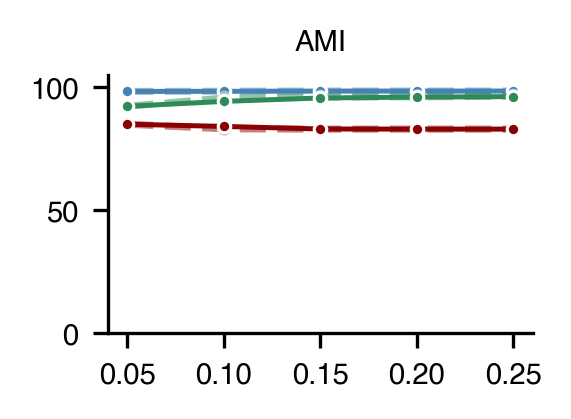

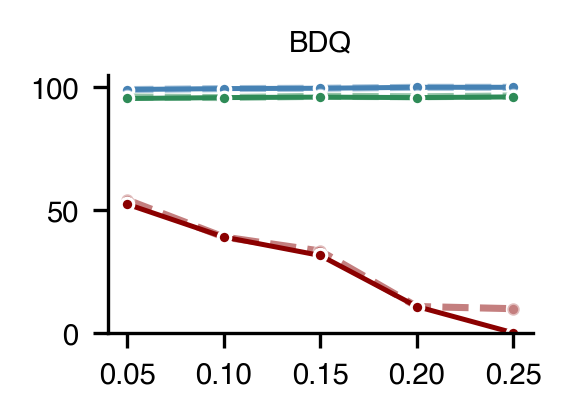

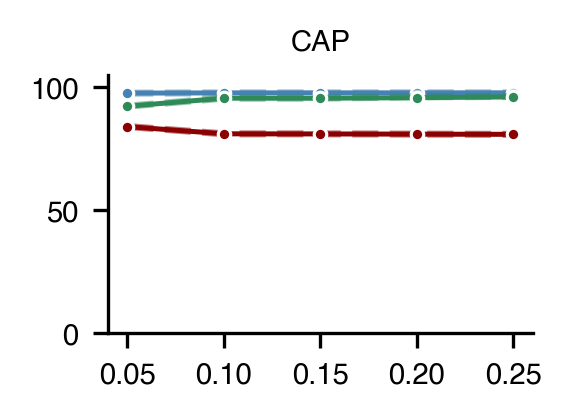

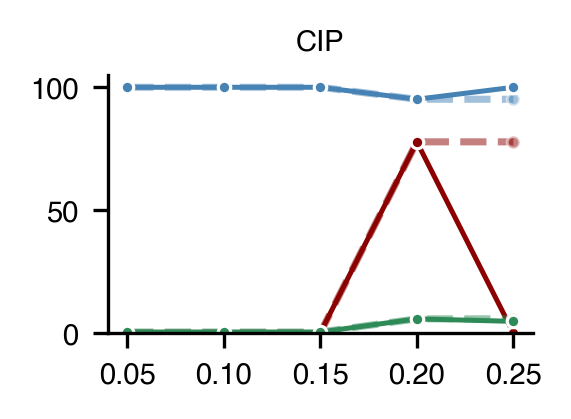

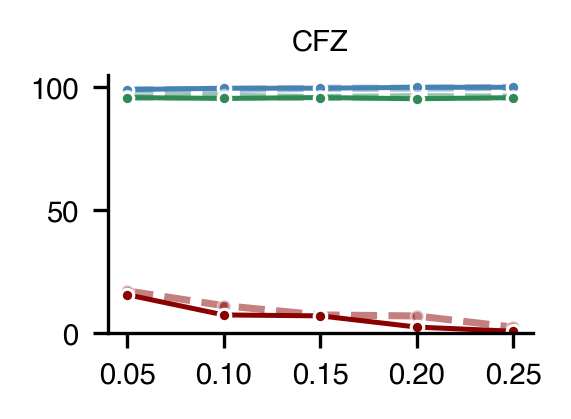

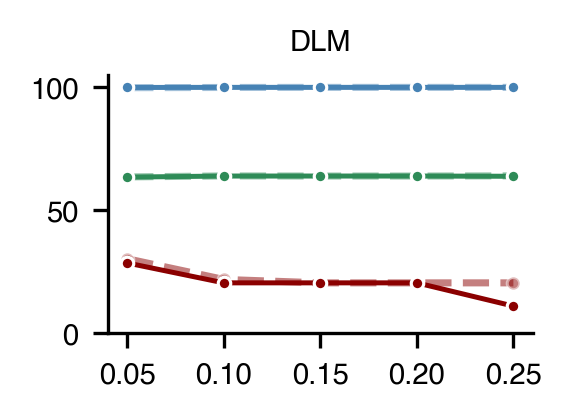

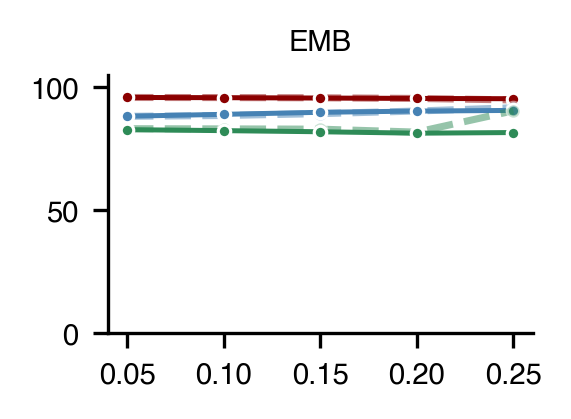

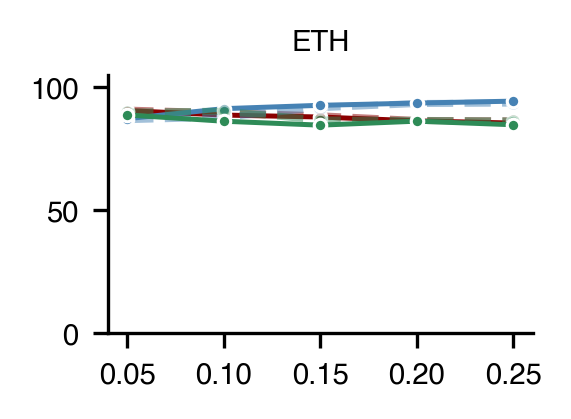

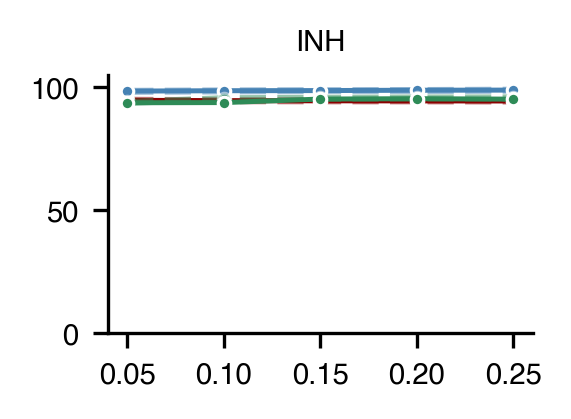

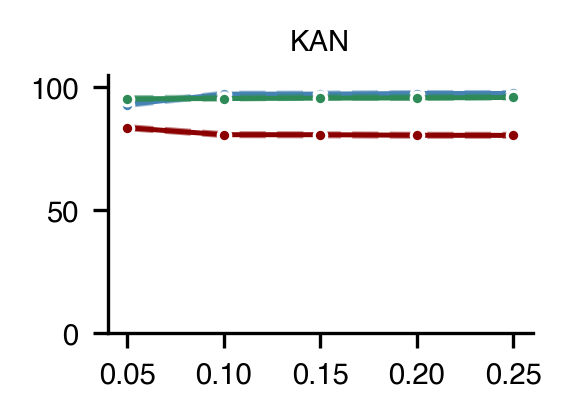

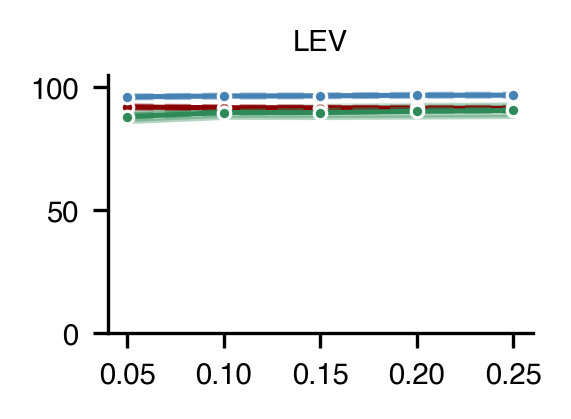

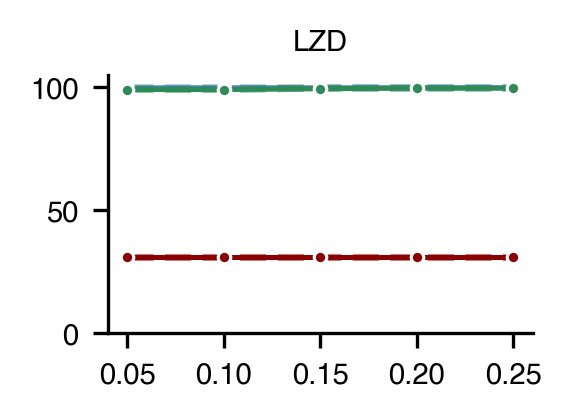

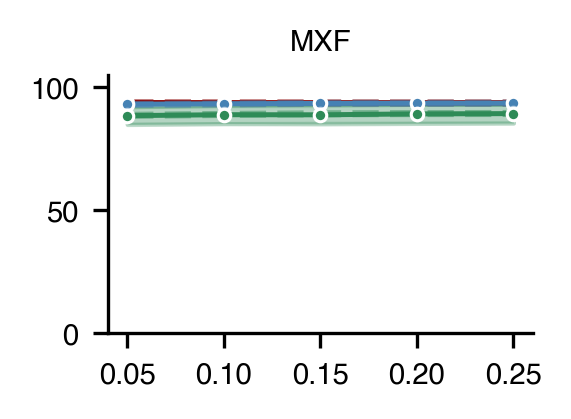

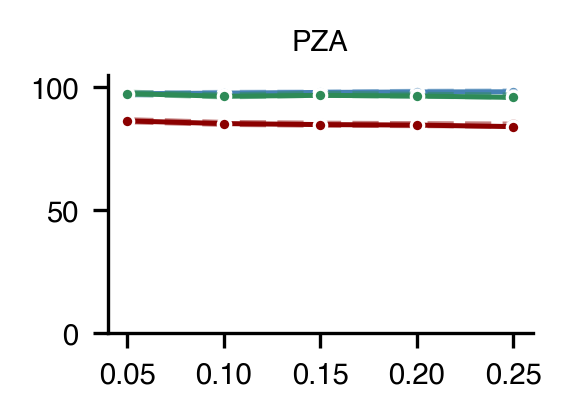

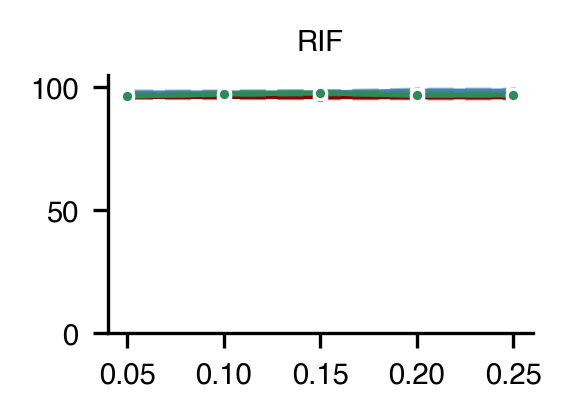

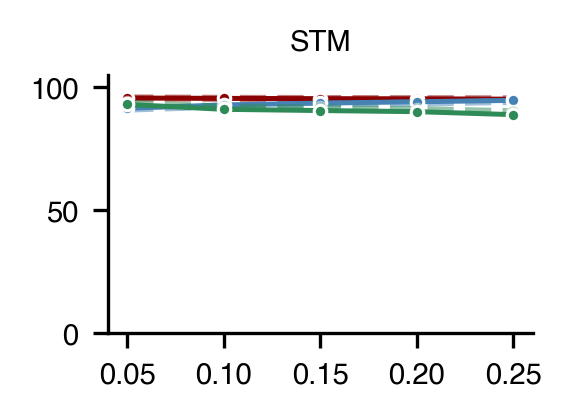

In [16]:

metric_colors = {
    "SENSITIVITY": "#8B0000",  # dark red
    "SPECIFICITY": "#4682B4",  # steel blue
    "DPR": "#2E8B57"           # sea green
}
for drug in melted_df["DRUG"].unique():
    drug_data = melted_df[melted_df["DRUG"] == drug]

    plt.figure(figsize=(2, 1.5))

    for metric in drug_data["Metric"].unique():
        for p in drug_data["p_value"].unique():
            subset = drug_data[
                (drug_data["Metric"] == metric) &
                (drug_data["p_value"] == p)
            ]
            sns.lineplot(
                data=subset,
                x="BACKGROUND_RATE",
                y="value",
                color=metric_colors[metric],
                alpha=0.5 if p == 0.90 else 1.0,  # Example: faded for 0.90, solid for 0.95
                marker="o",
                linestyle="--" if p == 0.90 else "-",  # Dashed for 0.90
                markersize=3,
                linewidth=1.7 if p == 0.9 else 1.2
            )

    plt.title(drug, fontsize=7)
    plt.xlabel("")
    plt.ylabel("")  # No y-label
    plt.ylim(0, 105)
    plt.tick_params(labelsize=7)
    sns.despine(top=True, right=True)
    plt.xticks(np.arange(0.05, 0.26, 0.05))  

    plt.tight_layout()
    plt.savefig(f'figs/grid_search/{drug}.pdf', transparent=True)

    plt.show()
    plt.close()


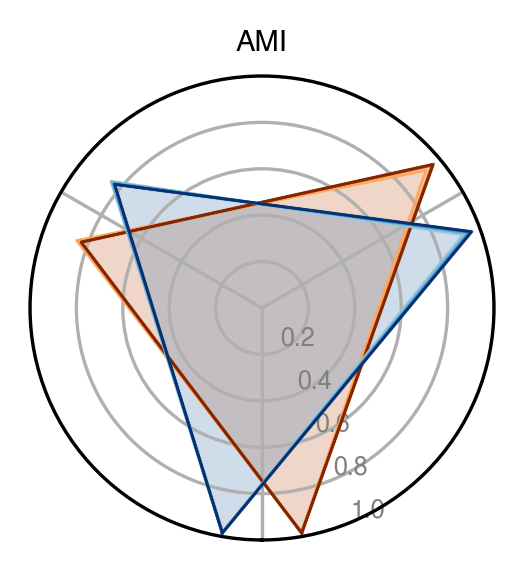

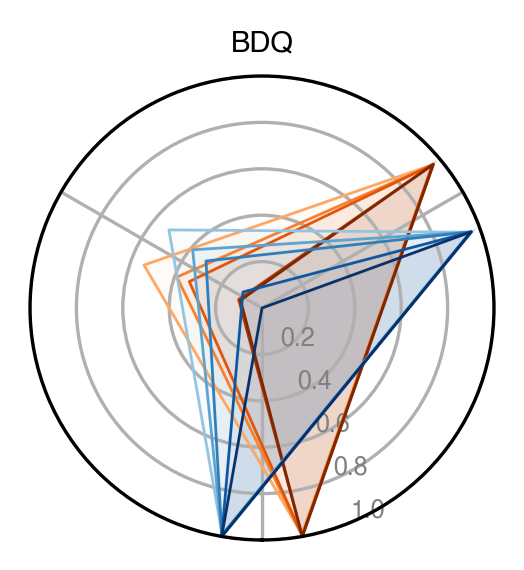

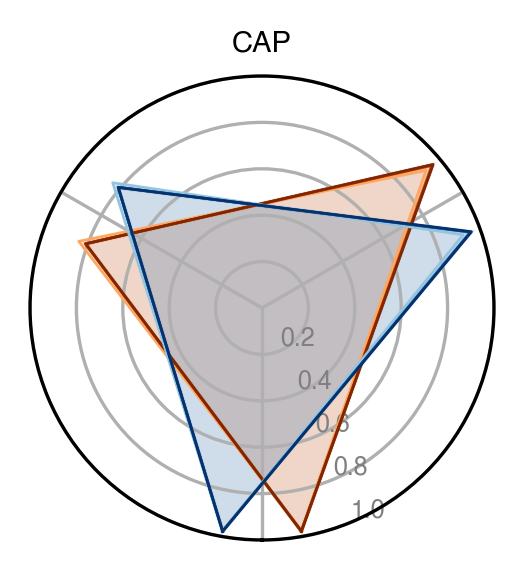

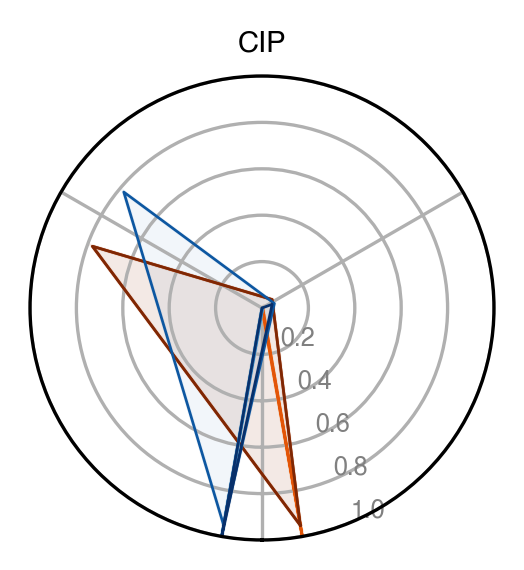

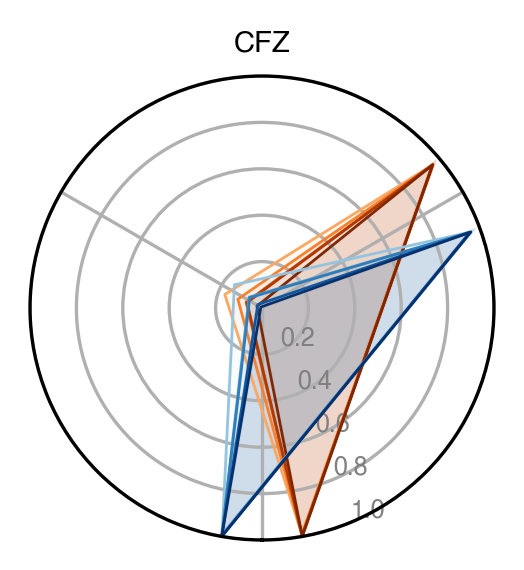

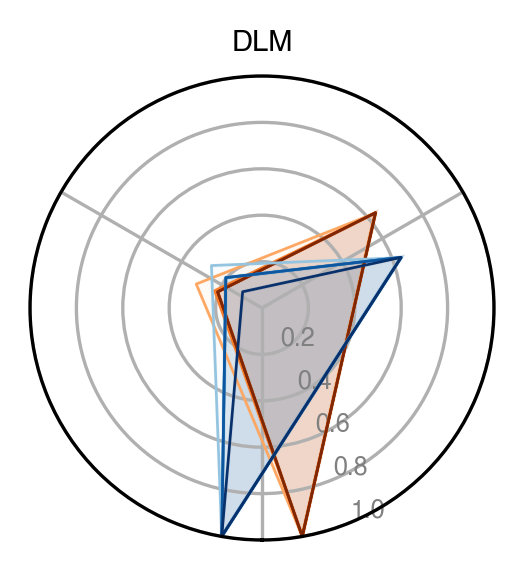

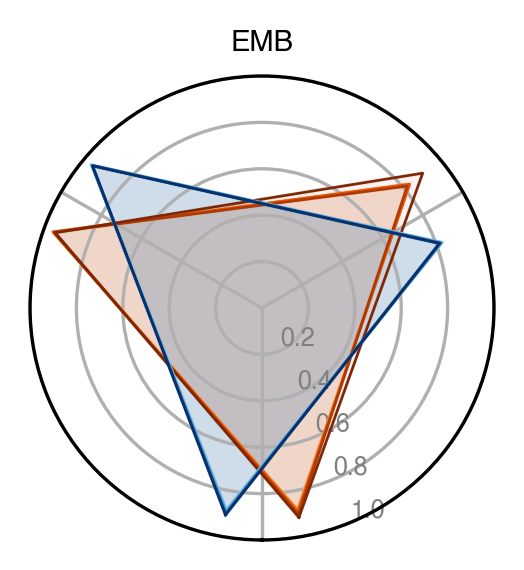

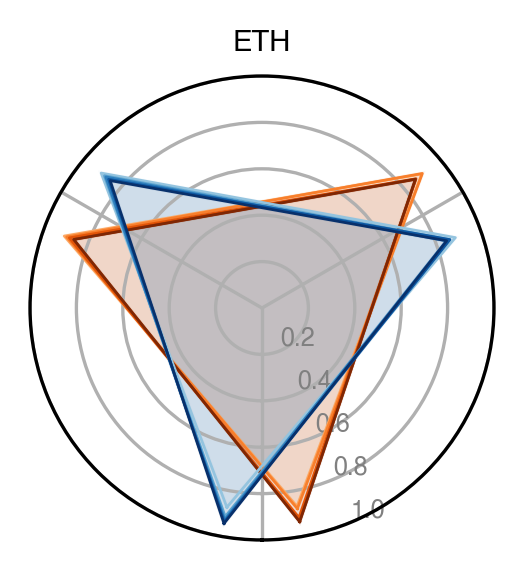

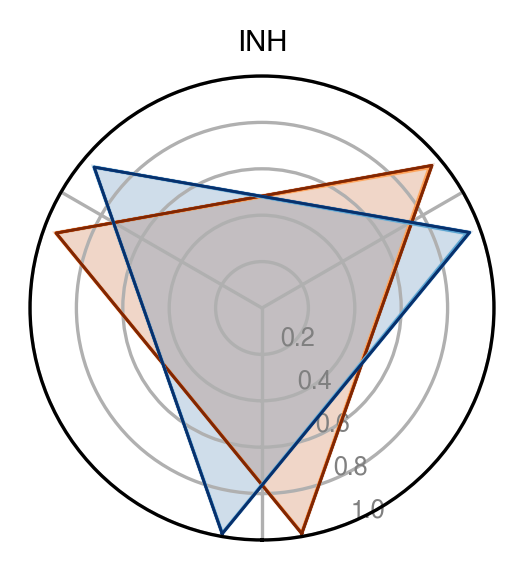

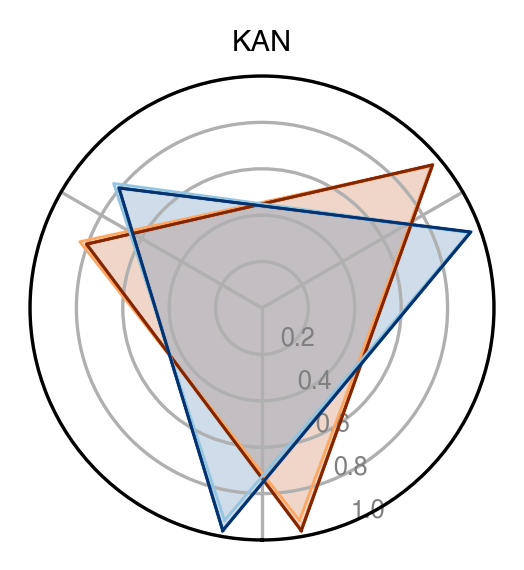

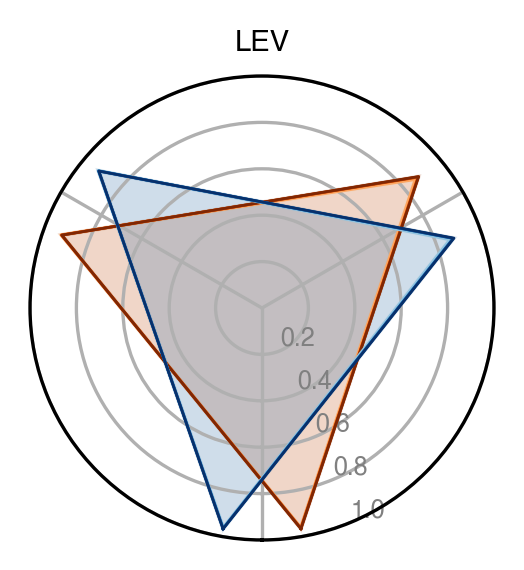

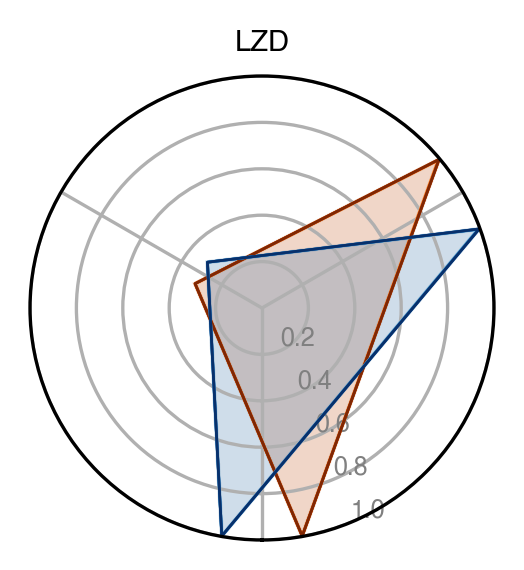

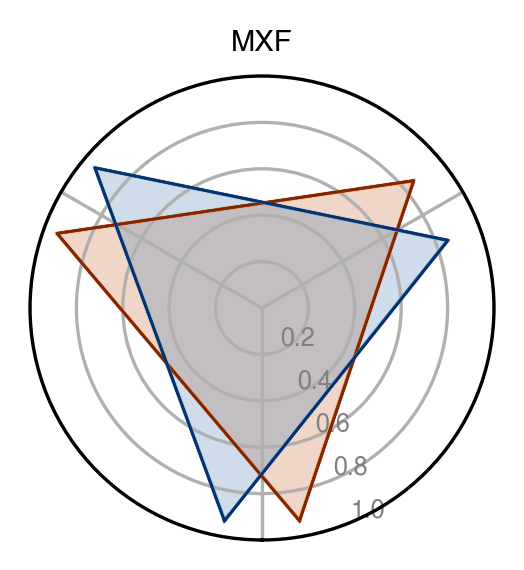

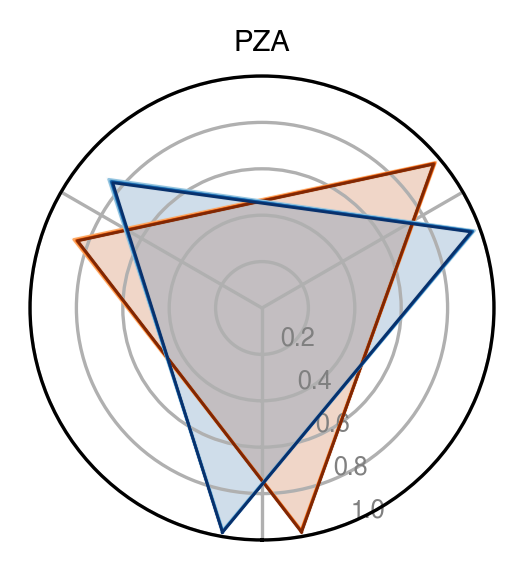

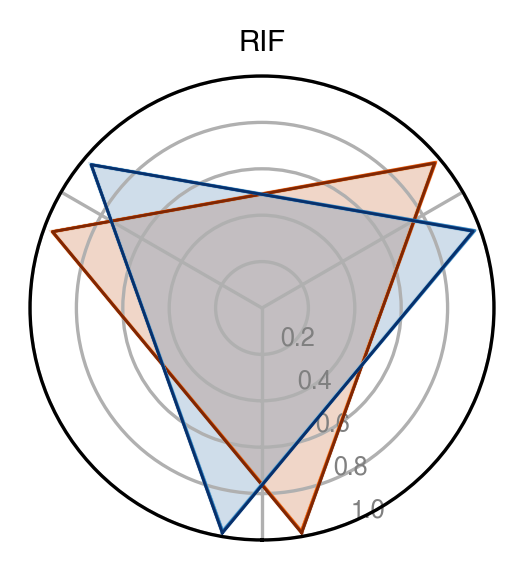

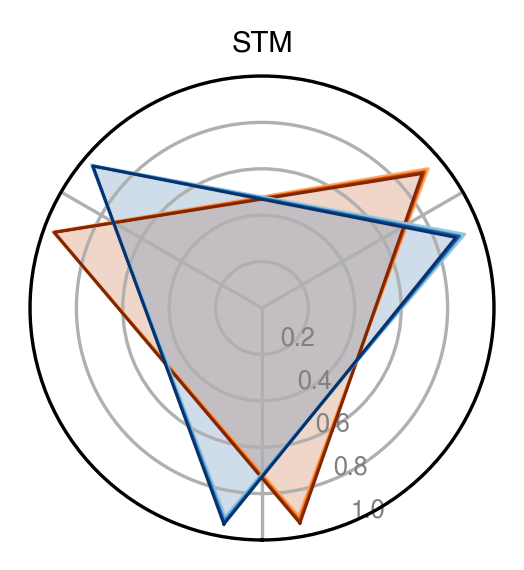

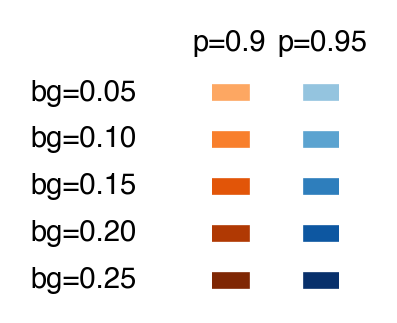

In [17]:
labels = ['SPECIFICITY', 'DPR', 'SENSITIVITY']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Unique values
drugs = df['DRUG'].unique()
p_values = df['p_value'].unique()

# Assign colormaps per p_value
pval_colormaps = {
    0.95: cm.Blues,
    0.90: cm.Oranges
}

# Angle shift for symmetric offset (±10 degrees)
angle_shift = np.deg2rad(10)

# Plot one radar chart per drug
for j, drug in enumerate(drugs):
    fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))
    subset = df[df['DRUG'] == drug]

    for p in p_values:
        sub_p = subset[subset['p_value'] == p]
        if sub_p.empty:
            continue

        background_rates = sorted(sub_p['BACKGROUND_RATE'].unique())
        color_map = pval_colormaps[p](np.linspace(0.4, 1, len(background_rates)))

        for i, rate in enumerate(background_rates):
            row = sub_p[sub_p['BACKGROUND_RATE'] == rate]
            if row.empty:
                continue

            values = [row[label].values[0] for label in labels]
            values += values[:1]

            # Symmetric angle offset for p-values
            if p == 0.95:
                angle_set = [(a - angle_shift) % (2 * np.pi) for a in angles]
            elif p == 0.90:
                angle_set = [(a + angle_shift) % (2 * np.pi) for a in angles]
            else:
                angle_set = angles

            ax.plot(angle_set, values,
                    label=f"p={p}, bg={rate}",
                    color=color_map[i], linewidth=0.65)
            ax.fill(angle_set, values, color=color_map[i], alpha=0.05)

    ax.set_theta_offset(-np.pi / 2)  # rotate 90° counterclockwise
    ax.set_xticks(angles[:-1])
    ax.tick_params(axis='y', labelsize=6, labelcolor='grey')
    if j == len(drugs):
        ax.set_xticklabels(['Specificity', 'DPR', 'Sensitivity'], fontsize=7)
    else:
        ax.set_xticklabels([''] * len(labels))
    ax.set_ylim(0, 1)
    ax.set_title(f"{drug}", fontsize=7)
    plt.tight_layout()
    plt.show()


#plot seperate legend:
# Prepare sorted unique values
bg_rates = sorted(df['BACKGROUND_RATE'].unique())
pvals = sorted(df['p_value'].unique())

# Create a small figure for the legend
fig, ax = plt.subplots(figsize=(1, 1))
ax.axis("off")  # turn off the axis

# Column headers (p-values)
for j, p in enumerate(pvals):
    ax.text(0.35 + j * 0.25, 0.9, f"p={p}", ha='center', va='bottom', fontsize=7)

# Row headers (background rates) and legend boxes
for i, bg in enumerate(bg_rates):
    y = 0.8 - i * 0.13
    ax.text(0.1, y, f"bg={bg:.2f}", ha='right', va='center', fontsize=7)
    for j, p in enumerate(pvals):
        # Get color for this bg/p combination
        cmap = pval_colormaps[p]
        color_index = bg_rates.index(bg)
        color = cmap(np.linspace(0.4, 1, len(bg_rates)))[color_index]
        
        # Draw a colored line as legend sample
        ax.plot([0.35 + j * 0.25 - 0.03, 0.35 + j * 0.25 + 0.03],
                [y, y], color=color, linewidth=4)

plt.tight_layout()
plt.show()


In [36]:
#determine the best performing catalogue
opt_cats_v1 = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

cat_counts = []

for i in opt_cats_v1.index:
    drug = opt_cats_v1['DRUG'][i]
    rate = opt_cats_v1['BACKGROUND_RATE'][i]
    pval = opt_cats_v1['p_value'][i]

    path = f"./catalogues/cryptic-v3.3.0/grid_search/{drug.lower()}/bg_{rate}_p_{pval}_FRS_0.1.csv"
    cat = pd.read_csv(path)

    # Filter out rows with '*' in MUTATION
    cat = cat[~cat['MUTATION'].str.contains(r'\*', na=False)]

    # Skip if empty after filtering
    if cat.empty:
        continue

    cat_counts.append({
        "DRUG": drug,
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    })

# Convert to DataFrame
cat_counts = pd.DataFrame(cat_counts)

# Merge and save
opt_cats_v1 = pd.merge(opt_cats_v1, cat_counts, on='DRUG')
opt_cats_v1['catalogue'] = 'catomatic_v3.3.0_train'
opt_cats_v1.to_csv('results/grid_search/opt_cats_v3.3.0_train.csv', index=False)

# Display result
opt_cats_v1


,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,DPR,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,148,148.0,RIF,0.25,0.90,0.960991,0.984595,0.971067,0.937937,0.985072,0.970087,41,23,352,416,catomatic_v3.3.0_train
1,88,88.0,INH,0.25,0.90,0.944220,0.988071,0.956626,0.916105,0.988683,0.959857,64,23,630,717,catomatic_v3.3.0_train
2,154,154.0,STM,0.15,0.90,0.954290,0.931818,0.914743,0.896104,0.938396,0.939639,115,8,545,668,catomatic_v3.3.0_train
3,18,NaN,MXF,0.25,0.90,0.933853,0.938610,0.931845,0.907982,0.943277,0.934879,11,23,520,554,catomatic_v3.3.0_train
4,8,NaN,LEV,0.25,0.90,0.909487,0.969160,0.932272,0.876678,0.971469,0.931946,13,20,359,392,catomatic_v3.3.0_train
5,68,68.0,EMB,0.25,0.90,0.948433,0.916507,0.904180,0.861001,0.924563,0.930005,16,54,1083,1153,catomatic_v3.3.0_train
6,130,130.0,PZA,0.05,0.90,0.863924,0.972718,0.976187,0.855799,0.973436,0.919015,440,0,144,584,catomatic_v3.3.0_train
7,0,0.0,AMI,0.05,0.90,0.849802,0.982971,0.922734,0.826923,0.984358,0.904339,12,6,393,411,catomatic_v3.3.0_train
8,20,20.0,CAP,0.05,0.90,0.840217,0.976051,0.922950,0.808577,0.977981,0.897514,43,2,236,281,catomatic_v3.3.0_train
9,70,70.0,ETH,0.05,0.90,0.907003,0.868226,0.898733,0.820353,0.881747,0.893716,296,1,348,645,catomatic_v3.3.0_train


In [37]:
rows = []

for idx,row in opt_cats_v1.iterrows():
    cat_path = pathlib.Path( "./catalogues/cryptic-v3.3.0/grid_search/") 
    cat =  cat_path / row.DRUG.lower() / f"bg_{row.BACKGROUND_RATE}_p_{row.p_value}_FRS_0.1.csv"
    if cat.is_file():
        df = pd.read_csv(cat)
        rows.append(df)

cat = pd.concat(rows)
cat.CATALOGUE_NAME = 'catomatic_v3.3.0'
cat.CATALOGUE_VERSION = '0.1'
cat = cat[['GENBANK_REFERENCE', 'CATALOGUE_NAME',
       'CATALOGUE_VERSION', 'CATALOGUE_GRAMMAR', 'PREDICTION_VALUES', 'DRUG',
       'MUTATION', 'PREDICTION', 'SOURCE', 'EVIDENCE', 'OTHER']]

cat.to_csv('catalogues/catomatic_v3.3.0.csv',index=False)
cat


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.008949117872666838, ""confiden...",{}
1,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0485...",{}
2,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,RIF,rpoB@S16C,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.1446...",{}
3,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,RIF,rpoB@E563D,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.2129...",{}
4,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
256,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,CFZ,atpE@-*_indel,U,{},"{""default_rule"": ""True""}",{}
257,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,CFZ,atpE@*_indel,U,{},"{""default_rule"": ""True""}",{}
258,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,CFZ,atpE@-*?,U,{},"{""default_rule"": ""True""}",{}
259,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,CFZ,atpE@*?,U,{},"{""default_rule"": ""True""}",{}


### PZA catalogue counts

Why does pyrazinamide have so many Rs and only 1 S?

In [38]:
cat[cat.DRUG == 'PZA'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()


np.int64(212)

In [ ]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_2715/3574174600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered.loc[:, 'mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,U
mut_type,,
indel,185,25
point,255,119


In [45]:
cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.apply(lambda x: 'ins' in x or 'del' in x))]


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@*=,S,{},"{""default_rule"": ""True""}",{}
2,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@H57D,R,{},"{""proportion"": 0.9783549783549783, ""confidence...",{}
3,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@V180F,R,{},"{""proportion"": 1.0, ""confidence"": [0.802594952...",{}
4,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@W68R,R,{},"{""proportion"": 0.9230769230769231, ""confidence...",{}
6,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@L182S,R,{},"{""proportion"": 0.6, ""confidence"": [0.392606369...",{}
...,...,...,...,...,...,...,...,...,...,...,...
581,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@A143S,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
582,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@T167P,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
583,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@Q122E,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
586,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@-*?,U,{},"{""default_rule"": ""True""}",{}


### ETH catalogue counts

Why does pyrazinamide have so many Rs and only 1 S?

In [46]:
cat[cat.DRUG == 'ETH'].MUTATION.apply(lambda x: 'ins' in x or 'del' in x).sum()


np.int64(203)

In [47]:
# Filter to only PZA and exclude mutations with '*'
filtered = cat[(cat.DRUG == 'ETH') & (~cat.MUTATION.str.contains(r'\*'))]

# Define mutation type: 'indel' for insertions/deletions, 'point' otherwise
filtered['mut_type'] = filtered.MUTATION.apply(
    lambda x: 'indel' if ('ins' in x or 'del' in x) else 'point'
)

# Crosstab of mutation type vs prediction
pd.crosstab(filtered['mut_type'], filtered['PREDICTION'])

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_2715/4234506190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['mut_type'] = filtered.MUTATION.apply(


PREDICTION,R,S,U
mut_type,,,
indel,121,0,76
point,175,1,272


In [ ]:
cat[(cat.DRUG == 'PZA') & (~cat.MUTATION.apply(lambda x: 'ins' in x or 'del' in x))]


,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@*=,S,{},"{""default_rule"": ""True""}",{}
2,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@H57D,R,{},"{""proportion"": 0.9783549783549783, ""confidence...",{}
3,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@V180F,R,{},"{""proportion"": 1.0, ""confidence"": [0.802594952...",{}
4,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@W68R,R,{},"{""proportion"": 0.9230769230769231, ""confidence...",{}
6,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@L182S,R,{},"{""proportion"": 0.6, ""confidence"": [0.392606369...",{}
...,...,...,...,...,...,...,...,...,...,...,...
581,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@A143S,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
582,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@T167P,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
583,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@Q122E,U,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.7301...",{}
586,NC00962.3,catomatic_v3.3.0,0.1,GARC1,RUS,PZA,pncA@-*?,U,{},"{""default_rule"": ""True""}",{}
